In [ ]:
import pandas as pd
import numpy as np
from zipf import fit_powerlaw_mle
from sampler import sample_zipf
from visualize import format_plot
from jitter import jitter
import matplotlib.pyplot as plt

In [68]:
np.random.seed(0)
N = 10_000
XMIN = 1
s = 2.5

smp = sample_zipf(N, s, XMIN)
smp_discrete = np.round(smp).astype(int)
smp_jitter = jitter(smp_discrete, XMIN)
s_hat_continuous, _, _, _ = fit_powerlaw_mle(smp, XMIN)
s_hat_discrete, _, _, _ = fit_powerlaw_mle(smp_discrete, XMIN)
s_hat_jitter, _, _, _ = fit_powerlaw_mle(smp_jitter, XMIN)
s, s_hat_continuous, s_hat_discrete, s_hat_jitter

(2.5,
 np.float64(2.514027484226264),
 np.float64(2.6617486468722964),
 np.float64(2.5082730799250785))

In [ ]:
df_estimates = pd.read_parquet("data/jitter_data.parquet")
df_estimates["continuous_sq_error"] = np.power(df_estimates["continuous"] - df_estimates["s"], 2)
df_estimates["discrete_sq_error"] = np.power(df_estimates["discrete"] - df_estimates["s"], 2)
df_estimates["jitter_sq_error"] = np.power(df_estimates["jitter"] - df_estimates["s"], 2)
df_estimates_grouped = df_estimates.groupby("s").agg({
    'continuous': ['mean', 'std'],
    'discrete': ['mean', 'std'],
    'jitter': ['mean', 'std'],
    'continuous_sq_error': ['mean', 'std'],
    'discrete_sq_error': ['mean', 'std'],
    'jitter_sq_error': ['mean', 'std'],
}).reset_index()

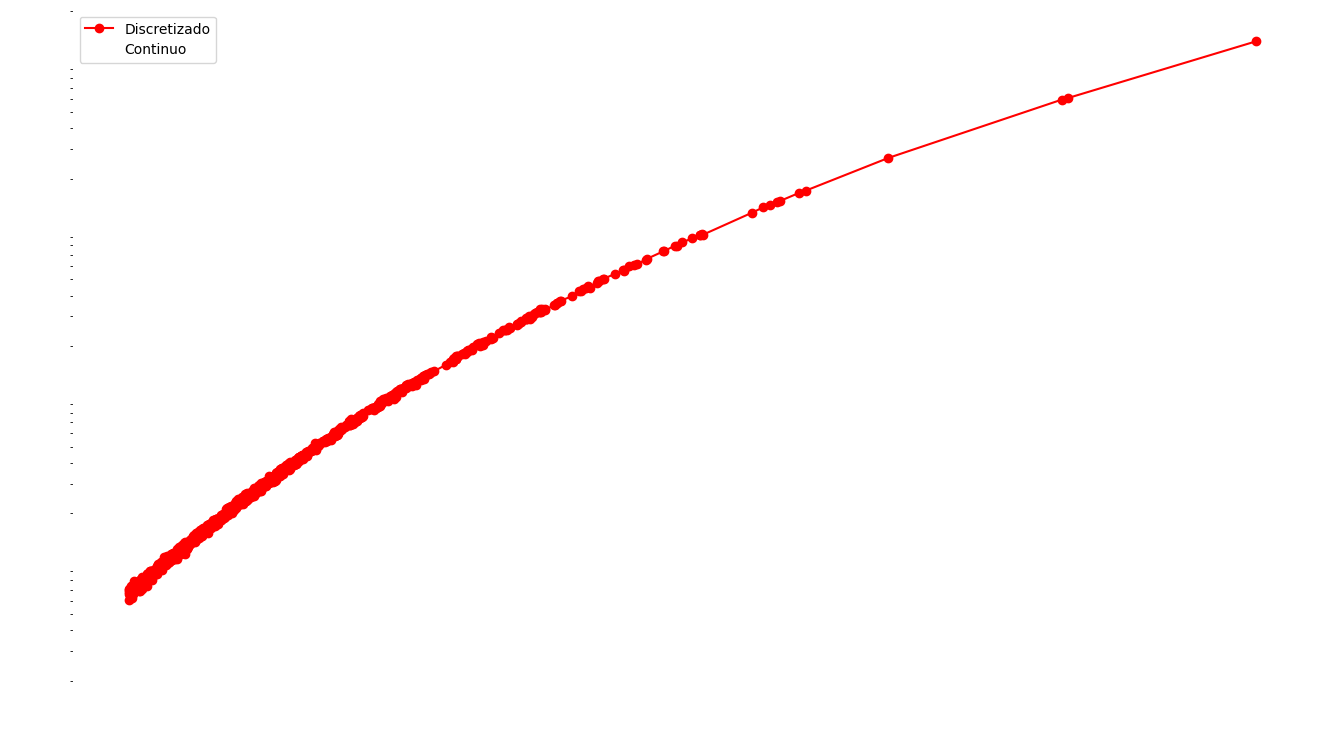

In [ ]:
fig = plt.figure(figsize=(16, 9))
ax = fig.add_subplot(111)

ax.plot(df_estimates_grouped["s"], df_estimates_grouped["discrete_sq_error"]["mean"], color="red", label=f"Discretizado", marker="o")
ax.plot(df_estimates_grouped["s"], df_estimates_grouped["continuous_sq_error"]["mean"], color="white", label=f"Continuo", marker="o")
ax.plot(df_estimates_grouped["s"], df_estimates_grouped["jitter_sq_error"]["mean"], color="orange", label=f"Jitter", marker="o", alpha=0.5)
ax.set_yscale("log")
ax.set_xlabel("$s$")
ax.set_ylabel("MSE")
format_plot(ax, "white")
plt.legend()
plt.savefig("assets/jitter_mse.png", transparent=True)
plt.show()